# Step 5 - Feature Engineering

Creating new columns that might be more useful than the raw ones.
Some of these are obvious (price per m²), some are experimental.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/cleaned.parquet')
print(f'{len(df):,} rows')

## Date features

In [2]:
# extract useful time components from date_mutation
df['mois'] = df['date_mutation'].dt.month
df['trimestre'] = df['date_mutation'].dt.quarter
df['jour_semaine'] = df['date_mutation'].dt.dayofweek  # 0=Monday

# sanity check
print('Month range:', df['mois'].min(), '-', df['mois'].max())
print('Quarter range:', df['trimestre'].min(), '-', df['trimestre'].max())

# is there a seasonal pattern in transaction volume?
by_month = df.groupby('mois').size()
print('\nTransactions per month:')
print(by_month)

Month range: 1 - 12
Quarter range: 1 - 4

Transactions per month:
mois
1     1376243
2     1389552
3     1693618
4     1571187
5     1528140
6     1913513
7     2073879
8     1293323
9     1804087
10    1737653
11    1521702
12    2284071
dtype: int64


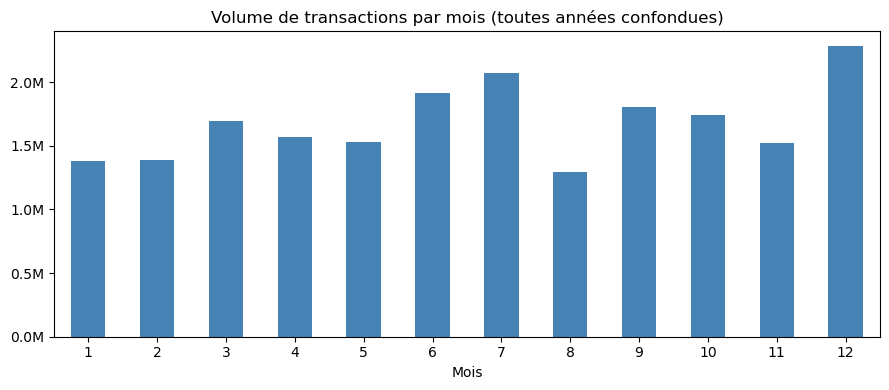

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
by_month.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Volume de transactions par mois (toutes années confondues)')
ax.set_xlabel('Mois')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/admin/Numerical Algo/Num Algo BackUp Test', dpi=100)
plt.show()

# spring/early summer usually peaks in French real estate market

Transaction count by day of week:
Mon    3336319
Tue    3918633
Wed    3705864
Thu    4080469
Fri    4762803
Sat     379039
Sun       3841
dtype: int64

Median valeur by day of week:
Mon    157450.0
Tue    146500.0
Wed    149000.0
Thu    149000.0
Fri    156380.0
Sat    115520.0
Sun     85200.0
Name: valeur_fonciere, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: 'Users/admin/Numerical Algo/Num Algo BackUp Test.png'

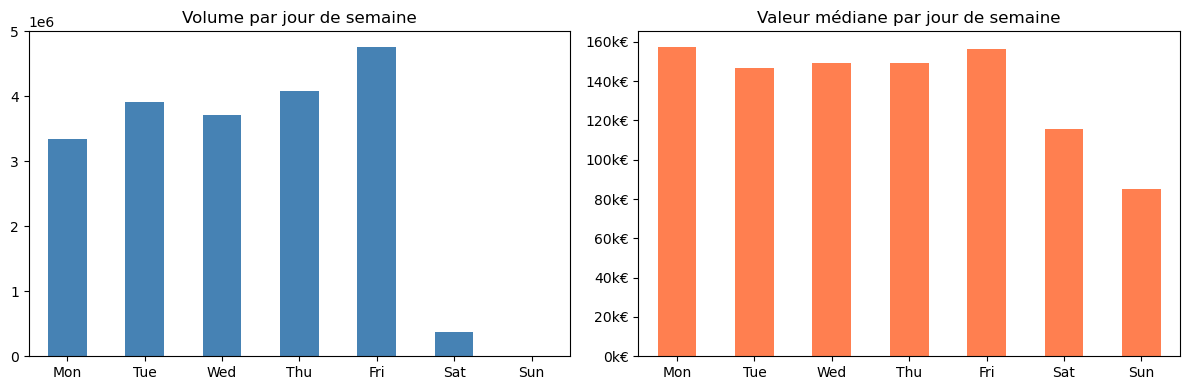

In [4]:
# jour_semaine added - does day of week actually affect transactions or price?
# if not, it's useless as a feature and should be dropped

# volume by day of week
dow_counts = df.groupby('jour_semaine').size()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts.index = dow_labels[:len(dow_counts)]
print('Transaction count by day of week:')
print(dow_counts)

# price by day of week (ventes only, no outliers)
ventes = df[(df['nature_mutation'] == 'Vente') & (~df['is_outlier_valeur'])]
dow_price = ventes.groupby('jour_semaine')['valeur_fonciere'].median()
dow_price.index = dow_labels[:len(dow_price)]
print('\nMedian valeur by day of week:')
print(dow_price.round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dow_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Volume par jour de semaine')
axes[0].set_xlabel('')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

dow_price.plot(kind='bar', ax=axes[1], color='coral', edgecolor='none')
axes[1].set_title('Valeur médiane par jour de semaine')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('Users/admin/Numerical Algo/Num Algo BackUp Test', dpi=100)
plt.show()

# conclusion: volume is heavily concentrated Mon-Fri (notarial acts are business hours)
# but price doesn't vary meaningfully by day - keeping mois and trimestre, dropping jour_semaine
df.drop(columns=['jour_semaine'], inplace=True)
print('\njour_semaine dropped - day of week does not affect price, only volume')

## Prix au m²

In [ ]:
# only meaningful when surface_bati > 0
mask_bati = df['surface_bati'] > 0
df.loc[mask_bati, 'prix_m2_bati'] = df.loc[mask_bati, 'valeur_fonciere'] / df.loc[mask_bati, 'surface_bati']

# same for terrain
mask_terrain = df['surface_terrain'] > 0
df.loc[mask_terrain, 'prix_m2_terrain'] = df.loc[mask_terrain, 'valeur_fonciere'] / df.loc[mask_terrain, 'surface_terrain']

print('Prix m² bâti:')
print(df['prix_m2_bati'].describe().round(1))
print('\nPrix m² terrain:')
print(df['prix_m2_terrain'].describe().round(1))

## Log de la valeur foncière

In [ ]:
# log transform is useful because valeur_fonciere is very skewed
# models usually work better with the log version
df['log_valeur'] = np.log1p(df['valeur_fonciere'])

print(df['log_valeur'].describe().round(3))

## Catégorie de taille (surface bâtie)

In [ ]:
# bucketing surface into size categories
# bin edges chosen based on the quartiles observed in EDA:
#   - tiny: <30m² (studios, very small apartments - median found in notebook 03 ~55m² for appts)
#   - small: 30-60m² (small apartments)
#   - medium: 60-100m² (typical apartment, small house - median maison ~95m²)
#   - large: 100-150m² (larger house)
#   - xlarge: 150-250m² (big house)
#   - huge: >250m² (villa, commercial, likely outlier in residential)

bins = [0, 30, 60, 100, 150, 250, float('inf')]
labels = ['tiny', 'small', 'medium', 'large', 'xlarge', 'huge']

df['taille_bati'] = pd.cut(
    df['surface_bati'],
    bins=bins,
    labels=labels,
    right=True
)

# rows with surface_bati == 0 are terrain/dépendance rows, not tiny buildings
df.loc[df['surface_bati'] == 0, 'taille_bati'] = np.nan

print('Distribution by taille_bati:')
print(df['taille_bati'].value_counts(dropna=False))

# sanity check: do size categories actually separate price well?
ventes_bati = df[
    df['taille_bati'].notna() &
    df['type_local'].isin(['Maison', 'Appartement']) &
    ~df['is_outlier_valeur']
]
print('\nMedian valeur by taille_bati:')
print(ventes_bati.groupby('taille_bati', observed=True)['valeur_fonciere'].median().apply(lambda x: f'{x:,.0f}€'))

## Région à partir du département

In [ ]:
# group departments into French administrative regions (2016 reform boundaries)
# source: INSEE COG (Code Officiel Géographique) - https://www.insee.fr/fr/information/2560452
# mapping verified against: https://www.data.gouv.fr/fr/datasets/code-officiel-geographique-cog/

region_map = {
    '01':'ARA','03':'ARA','07':'ARA','15':'ARA','26':'ARA','38':'ARA','42':'ARA','43':'ARA','63':'ARA','69':'ARA','73':'ARA','74':'ARA',
    '21':'BFC','25':'BFC','39':'BFC','58':'BFC','70':'BFC','71':'BFC','89':'BFC','90':'BFC',
    '22':'BRE','29':'BRE','35':'BRE','56':'BRE',
    '18':'CVL','28':'CVL','36':'CVL','37':'CVL','41':'CVL','45':'CVL',
    '75':'IDF','77':'IDF','78':'IDF','91':'IDF','92':'IDF','93':'IDF','94':'IDF','95':'IDF',
    '11':'OCC','12':'OCC','30':'OCC','31':'OCC','32':'OCC','34':'OCC','46':'OCC','48':'OCC','65':'OCC','66':'OCC','81':'OCC','82':'OCC','09':'OCC',
    '06':'SUD','13':'SUD','83':'SUD','84':'SUD','04':'SUD','05':'SUD',
    '2A':'SUD','2B':'SUD',
    '44':'PDL','49':'PDL','53':'PDL','72':'PDL','85':'PDL',
    '02':'HDF','59':'HDF','60':'HDF','62':'HDF','80':'HDF',
    '08':'GES','10':'GES','51':'GES','52':'GES','54':'GES','55':'GES','57':'GES','67':'GES','68':'GES','88':'GES',
    '14':'NOR','27':'NOR','50':'NOR','61':'NOR','76':'NOR',
    '16':'NAQ','17':'NAQ','19':'NAQ','23':'NAQ','24':'NAQ','33':'NAQ','40':'NAQ','47':'NAQ','64':'NAQ','79':'NAQ','86':'NAQ','87':'NAQ',
    '971':'DOM','972':'DOM','973':'DOM','974':'DOM','976':'DOM',
}

df['region'] = df['code_departement'].map(region_map)

# spot-check a few key departments
spot_checks = {'75': 'IDF', '69': 'ARA', '33': 'NAQ', '59': 'HDF', '13': 'SUD', '67': 'GES'}
print('Spot-check region mapping:')
for dept, expected in spot_checks.items():
    got = region_map.get(dept, 'NOT FOUND')
    status = 'OK' if got == expected else f'WRONG - got {got}'
    print(f'  dept {dept} -> {got} (expected {expected}) [{status}]')

unmapped = df['region'].isnull().sum()
print(f'\nUnmapped: {unmapped:,} ({unmapped/len(df)*100:.1f}%)')
print('Unmapped dept codes (top 5):')
print(df[df['region'].isnull()]['code_departement'].value_counts().head())

print('\nTransactions per region:')
print(df['region'].value_counts())

## Indicateur bien résidentiel

In [ ]:
# boolean flag: is it a residential property?
# useful for filtering in future analysis or modeling
df['is_residentiel'] = df['type_local'].isin(['Maison', 'Appartement'])

print(df['is_residentiel'].value_counts())
print(f'\n{df["is_residentiel"].mean()*100:.1f}% of transactions are residential')

## Check final dataframe

In [ ]:
new_features = ['mois', 'trimestre', 'prix_m2_bati', 'prix_m2_terrain',
                'log_valeur', 'taille_bati', 'region', 'is_residentiel']

print('New features added:')
print(df[new_features].dtypes)
print(f'\nTotal columns now: {df.shape[1]}')
print('\n(jour_semaine was dropped - see analysis above)')

In [ ]:
# prix_m2_bati by region - quick sanity check
res = df[df['is_residentiel'] & df['prix_m2_bati'].notna() & (df['prix_m2_bati'] < 20000)]

region_prix = res.groupby('region')['prix_m2_bati'].median().sort_values(ascending=False)
print('Median prix/m² by region (residential):')
print(region_prix.round(0))

fig, ax = plt.subplots(figsize=(10, 4))
region_prix.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Prix médian au m² par région (biens résidentiels)')
ax.set_xlabel('Région')
ax.set_ylabel('€/m²')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/plots/16_prix_m2_region.png', dpi=100)
plt.show()

# IDF should clearly be the most expensive

In [ ]:
# save final engineered dataset
df.to_parquet('../data/features.parquet', index=False)
print(f'Saved: {df.shape[0]:,} rows, {df.shape[1]} columns')
print('Done.')